[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wjd123p/IT326-Project/blob/main/Phase2.ipynb)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv("Raw_dataset.csv")
df_raw = df.copy()

df_raw.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


# Phase 2: Data Summarization and Preprocessing

## Q1 - Data Analysis

### Raw Dataset Snapshot

### 1. Statistical Summary

In [ ]:
# Statistical Summary

df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


The statistical summary provides an overview of the numerical attributes in the dataset, including their mean, standard deviation, minimum, and maximum values. The results show that the average study time is 3.57 hours, the average attendance is 85.09%, the average sleep duration is 6.80 hours, the average previous grade is 69.74, and the average final exam score is 83.54. This helps in understanding the central tendency and spread of the numerical attributes.

### 2. Five Number Summary

In [ ]:
df.describe().loc[['min', '25%', '50%', '75%', 'max']]

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
min,1.00,0.5,54.8,3.2,31.3,46.800
25%,250.75,2.6,78.8,5.9,61.0,76.075
50%,500.50,3.6,85.2,6.8,69.6,83.800
75%,750.25,4.5,91.9,7.6,78.4,91.525
max,1000.00,8.1,100.0,10.0,100.0,100.000


### 3. Histogram

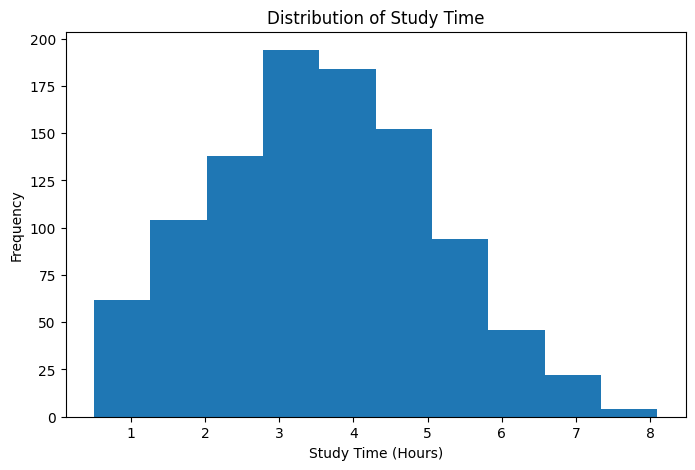

In [ ]:
# Histogram
plt.figure(figsize=(8,5))
plt.hist(df['study_time_hours'], bins=10)
plt.xlabel('Study Time (Hours)')
plt.ylabel('Frequency')
plt.title('Distribution of Study Time')
plt.show()

The histogram shows the distribution of students' study time. Most students study between 2 and 5 hours, with the highest frequency around 3 to 4 hours. The frequency decreases as study time increases. This helps understand the distribution of the study time variable and identify the most common values.

## Q2 - Data Preprocessing
### 1. Normalization

In [ ]:
# Min-Max Normalization

numeric_columns = [
    'study_time_hours',
    'attendance_percent',
    'sleep_hours',
    'previous_grade',
    'final_exam_score'
]

df_normalized = df.copy()

for col in numeric_columns:
    df_normalized[col] = (
        (df_normalized[col] - df_normalized[col].min()) /
        (df_normalized[col].max() - df_normalized[col].min())
    )

df_normalized.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,0.460526,0.955752,0.485294,Bachelors,Yes,Yes,No,0.663755,1.000000,A
1,2,Female,0.763158,1.000000,0.367647,High School,Yes,Yes,Yes,0.643377,1.000000,A
2,3,Male,0.578947,0.674779,0.691176,Bachelors,Yes,No,Yes,0.832606,0.949248,A
3,4,Male,0.276316,0.502212,0.705882,NaN,Yes,Yes,No,0.783115,0.695489,B
4,5,Male,0.223684,0.769912,0.205882,Bachelors,Yes,No,Yes,0.443959,0.404135,D


Normalization was applied to the numerical attributes using Min-Max Normalization. The values were transformed to a common range between 0 and 1. This gives the numerical attributes a similar scale and prevents attributes with larger ranges from having a greater effect on the analysis.

In [18]:
missing_values = df.isna().sum()
print("Missing values in each column:")
print(missing_values)
print("\nTotal number of missing values in the dataset:", missing_values.sum())

Missing values in each column:
student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64

Total number of missing values in the dataset: 102


### Missing Values Analysis

**Description:** The table lists the number and percentage of missing values in each column, and the missingno matrix visualizes them, where white gaps represent missing entries and dark areas represent complete data.

**Information provided:** Only `parental_education` contains missing values (102 out of 1000 records, about 10.2%), while all other 11 attributes are complete. The gaps are scattered across all rows without a clear pattern, which suggests the values are missing at random.

**How it helped decide preprocessing:** Deleting these rows would waste about 10% of the data, so the dataset needs imputation.

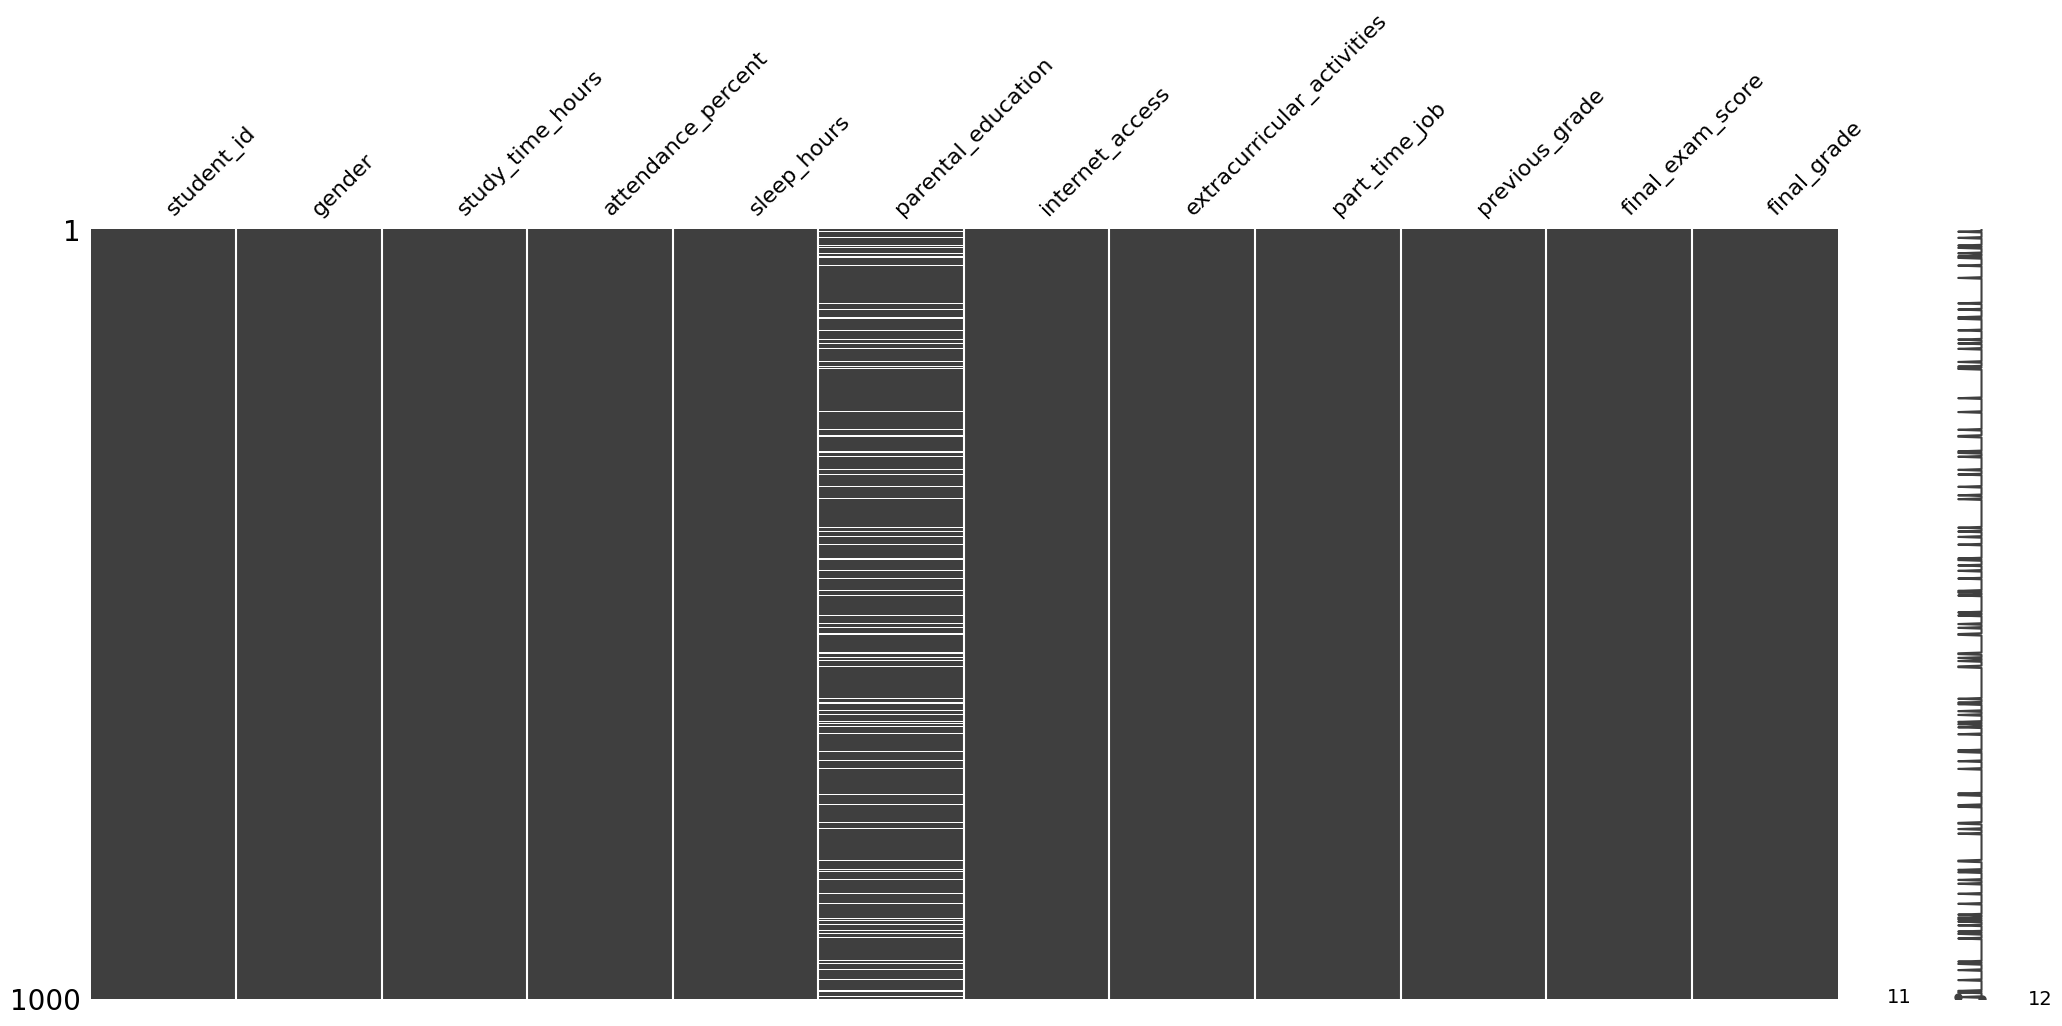

In [19]:
import matplotlib.pyplot as plt
import missingno as msno

msno.matrix(df)
plt.show()

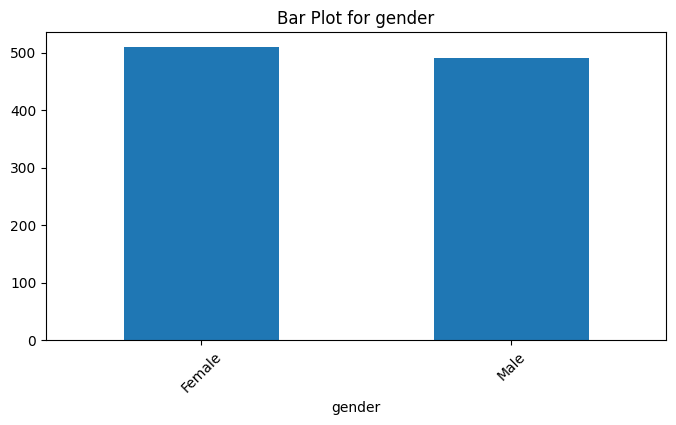

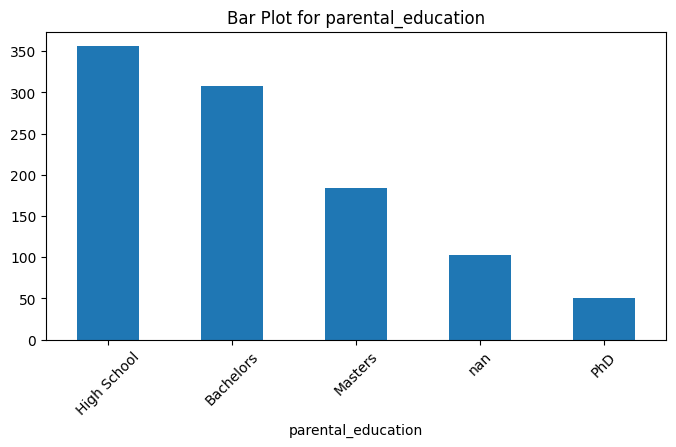

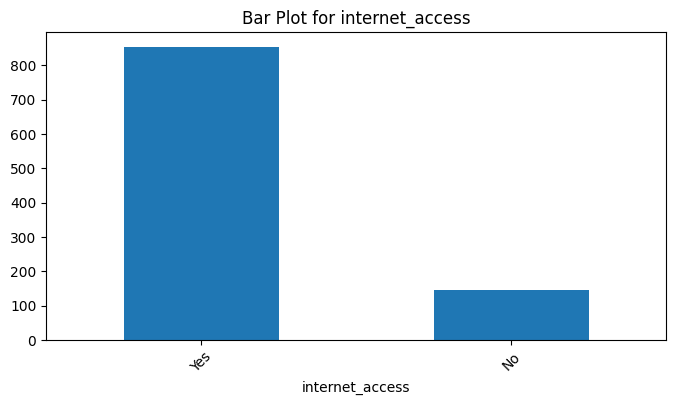

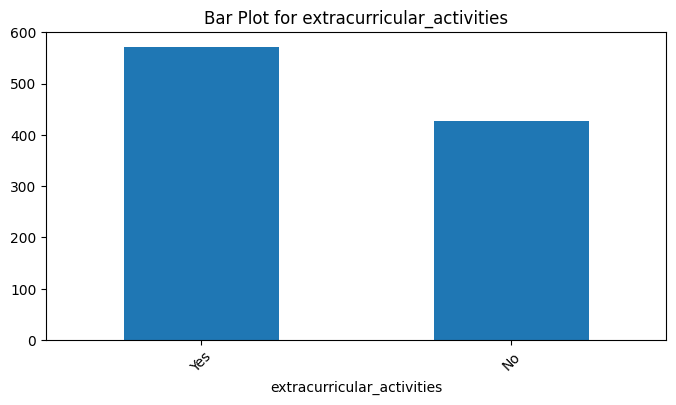

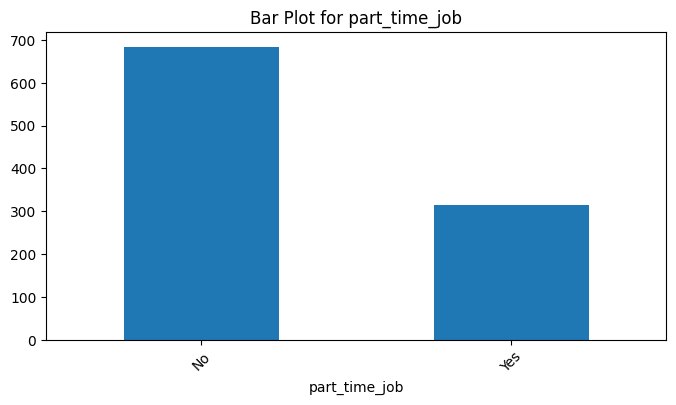

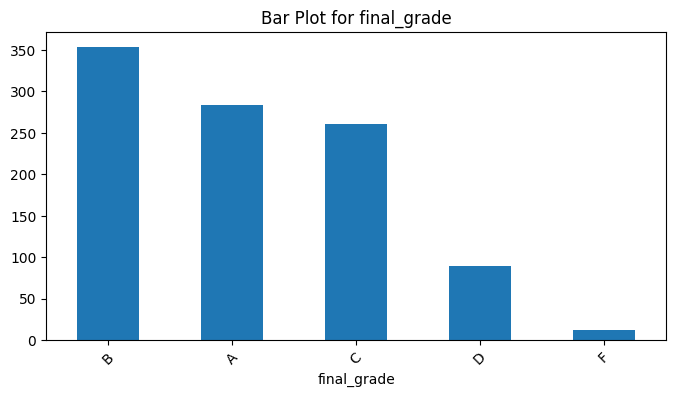

In [20]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
  df[col].value_counts(dropna=False).plot(kind='bar', figsize=(8, 4))
  plt.title(f'Bar Plot for {col}')
  plt.xticks(rotation=45)
  plt.show()

### Bar Plot: gender

**Description:** This bar plot shows the number of students in each gender category.

**Information provided:** The two categories are fairly balanced, with slightly more females than males, so there is no serious imbalance in this attribute.

**How it helped decide preprocessing:** No cleaning is needed, but since the values are text (Female/Male), the attribute must be encoded into numbers before modeling.

### Bar Plot: parental_education

**Description:** This bar plot shows the frequency of each parental education level, including a separate bar for missing values (NaN).

**Information provided:** High School is the most common level, followed by Bachelors and Masters, while PhD is the rarest. The NaN bar (102 records) confirms the missing values found earlier, and it is the only attribute where such a bar appears.

**How it helped decide preprocessing:** The NaN bar shows that this attribute needs imputation. Its categories also have a natural order (High School < Bachelors < Masters < PhD), so it should be encoded accordingly.

### Bar Plot: internet_access

**Description:** This bar plot shows how many students have internet access (Yes) and how many do not (No).

**Information provided:** The distribution is clearly imbalanced, as most students have internet access and only a small group does not.

**How it helped decide preprocessing:** The attribute has no missing values, but it is a binary text attribute (Yes/No) that must be encoded into 0/1 for the algorithms.

### Bar Plot: extracurricular_activities

**Description:** This bar plot shows how many students participate in extracurricular activities (Yes) and how many do not (No).

**Information provided:** Both categories have a substantial number of students, with Yes being more frequent than No, so the attribute is reasonably balanced and informative.

**How it helped decide preprocessing:** No missing values or noise were found, but the Yes/No text values must be encoded into numeric form.

### Bar Plot: part_time_job

**Description:** This bar plot shows how many students have a part-time job (Yes) and how many do not (No).

**Information provided:** Most students do not have a part-time job, while a smaller group does, so this attribute is moderately imbalanced.

**How it helped decide preprocessing:** The attribute is complete, but it is a binary text attribute, so it must be encoded into 0/1.

In [21]:
df['parental_education'] = df['parental_education'].fillna(df['parental_education'].mode()[0])

print("Missing values after imputation:")
print(df.isna().sum())

Missing values after imputation:
student_id                    0
gender                        0
study_time_hours              0
attendance_percent            0
sleep_hours                   0
parental_education            0
internet_access               0
extracurricular_activities    0
part_time_job                 0
previous_grade                0
final_exam_score              0
final_grade                   0
dtype: int64


Preprocessing Technique: Imputation (Mode)
Why: Most data mining algorithms cannot handle missing values, and removing the 102 incomplete rows would discard about 10% of the dataset.

How and on which attribute: We applied it on parental_education only, since it is the only attribute with missing values. Because it is categorical, mean and median cannot be used, so the missing entries were replaced with the most frequent category (mode).

Result: The number of missing values dropped from 102 to 0, and all 1000 records were preserved.

Improvement: The dataset is now complete and ready for the following preprocessing steps and for classification and clustering.